# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They help model nonlinear relationships and probabilities, which basic linear models can’t handle well.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross entropy works because it compares predicted probabilities to real outcomes and penalizes confident wrong predictions.
1. True or false, and explain: Logistic regression is a linear model.

True, It’s linear in the inputs log odds, but the final output is nonlinear.
4. True or false, and explain: Logistic regression cannot be used for classification.

False, Logistic regression is used for classification a lot of the times.
1. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. Coefficients show change in log odds, but not direct probability.
1. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False, It still relies on a linear combination of features, so feature engineering is important.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False, Logistic regression is better for classification. OLS is better for predicting continuous values.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


## 1)

In [ ]:
import pandas as pd


df = pd.read_csv("data/data.csv", sep=';')


cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df[cols]


df = df.dropna()


df['dropout'] = (df['Target'] == 'Dropout').astype(int)

## 2)

In [2]:
from sklearn.linear_model import LogisticRegression

X = df[['Debtor','Tuition fees up to date','Scholarship holder','Age at enrollment']]
y = df['dropout']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(model.coef_)

[[ 0.53062542 -2.55654243 -1.22744152  0.04992541]]


Debt and older age increase dropout. Being up to date on tuition and having a scholarship decrease dropout. Yes, being up to date lowers risk.

## 3)

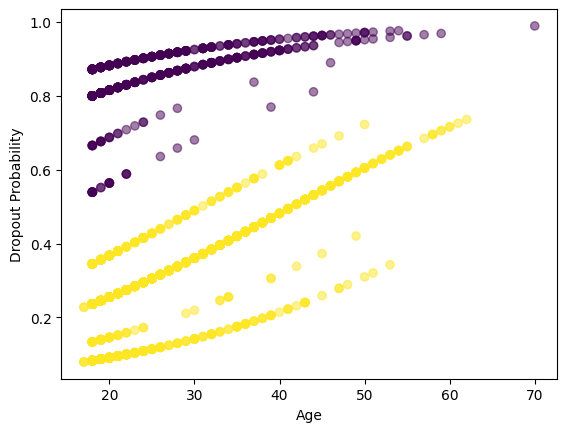

In [3]:
import matplotlib.pyplot as plt

probs = model.predict_proba(X)[:,1]
df['prob'] = probs

plt.scatter(df['Age at enrollment'], df['prob'],
            c=df['Tuition fees up to date'], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Dropout Probability")
plt.show()

Dropout increases with age. Students up to date on tuition have lower dropout, especially at younger ages. It lowers dropout by about 0.1–0.3.

## 4)

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[2841  162]
 [ 891  530]]
0.7619801084990958


The model is about 76% accurate, so it does a decent job but is not perfect.

## 5)

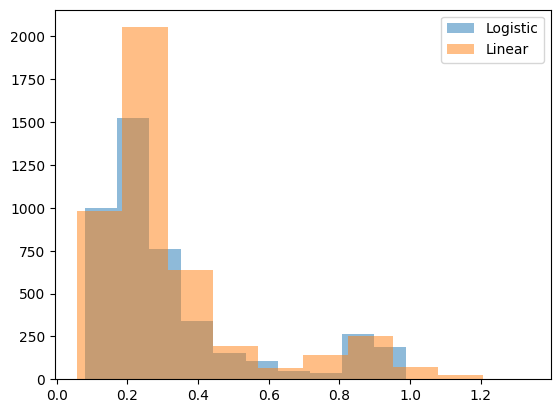

In [5]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

lin_probs = lin.predict(X)

plt.hist(probs, alpha=0.5, label='Logistic')
plt.hist(lin_probs, alpha=0.5, label='Linear')
plt.legend()
plt.show()

Logistic is better because it keeps probabilities between 0 and 1. Linear can give invalid values.

## 6)

The model mostly predicts the most common class, so some classes may be missed in hard predictions. But the predicted probabilities include all classes, even if they aren’t always chosen.

## 7)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

multi_X = df[['Debtor','Tuition fees up to date','Curricular units 1st sem (approved)']]
multi_y = df['Target']

multi = LogisticRegression(max_iter=1000)
multi.fit(multi_X, multi_y)

preds = multi.predict(multi_X)
print(confusion_matrix(multi_y, preds))

probs_multi = multi.predict_proba(multi_X)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


The model mostly predicts the main classes and misses some classes. But the probabilities still include all classes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

## 1)

In [9]:
import pandas as pd

df = pd.read_csv("data/cirrhosis.csv")

cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols]

df = df.dropna()

df['Stage'] = df['Stage'].astype(int)

df['survive'] = df['Status'].isin(['C','CL']).astype(int)

## 2)

In [10]:
from sklearn.linear_model import LogisticRegression

X = pd.get_dummies(df[['Edema','Drug','Bilirubin']], drop_first=True)
y = df['survive']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(model.coef_)

[[-0.3514239  -0.45067663 -1.61104918  0.23122512]]


The drug slightly lowers survival. Higher bilirubin slightly increases survival in this model. Worse edema lowers survival.

## 3)

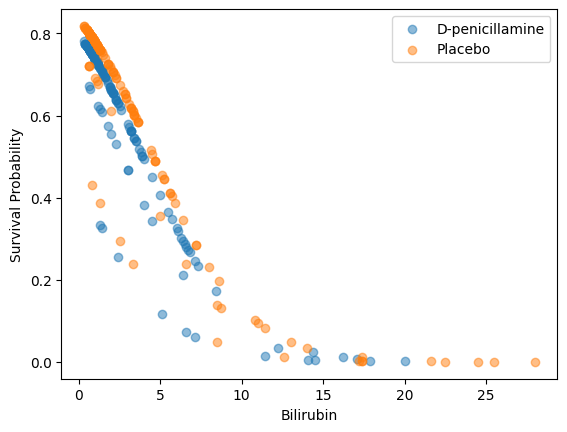

In [11]:
import matplotlib.pyplot as plt

df['prob'] = model.predict_proba(X)[:,1]

for drug in df['Drug'].unique():
    sub = df[df['Drug']==drug]
    plt.scatter(sub['Bilirubin'], sub['prob'], alpha=0.5, label=drug)

plt.xlabel("Bilirubin")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [12]:
df.groupby('Drug')['prob'].mean()

Drug
D-penicillamine    0.590054
Placebo            0.608902
Name: prob, dtype: float64

Survival decreases as bilirubin increases. The drug does not clearly help. The average effect of the drug is small.

## 4)

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[ 59  66]
 [ 16 171]]
0.7371794871794872


The model is about 74% accurate, so it works okay but not perfectly.

## 5)

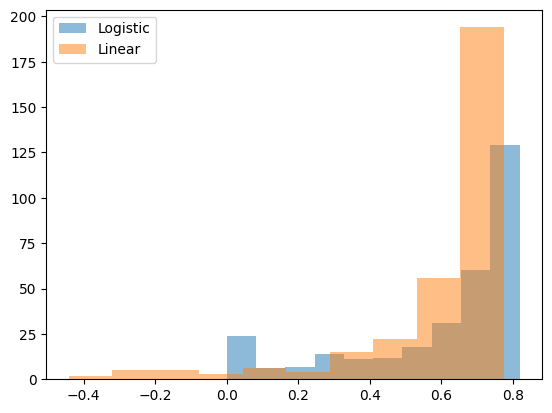

In [14]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

lin_probs = lin.predict(X)

plt.hist(df['prob'], alpha=0.5, label='Logistic')
plt.hist(lin_probs, alpha=0.5, label='Linear')
plt.legend()
plt.show()

Logistic is better because it keeps values between 0 and 1. Linear can give invalid values.

## 6)

In [15]:
multi_X = pd.get_dummies(df[['Edema','Bilirubin']], drop_first=True)
multi_y = df['Stage']

multi = LogisticRegression(max_iter=1000)
multi.fit(multi_X, multi_y)

preds = multi.predict(multi_X)
print(confusion_matrix(multi_y, preds))

probs_multi = multi.predict_proba(multi_X)

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]


The model mostly predicts one stage and misses others. But probabilities still include all stages.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

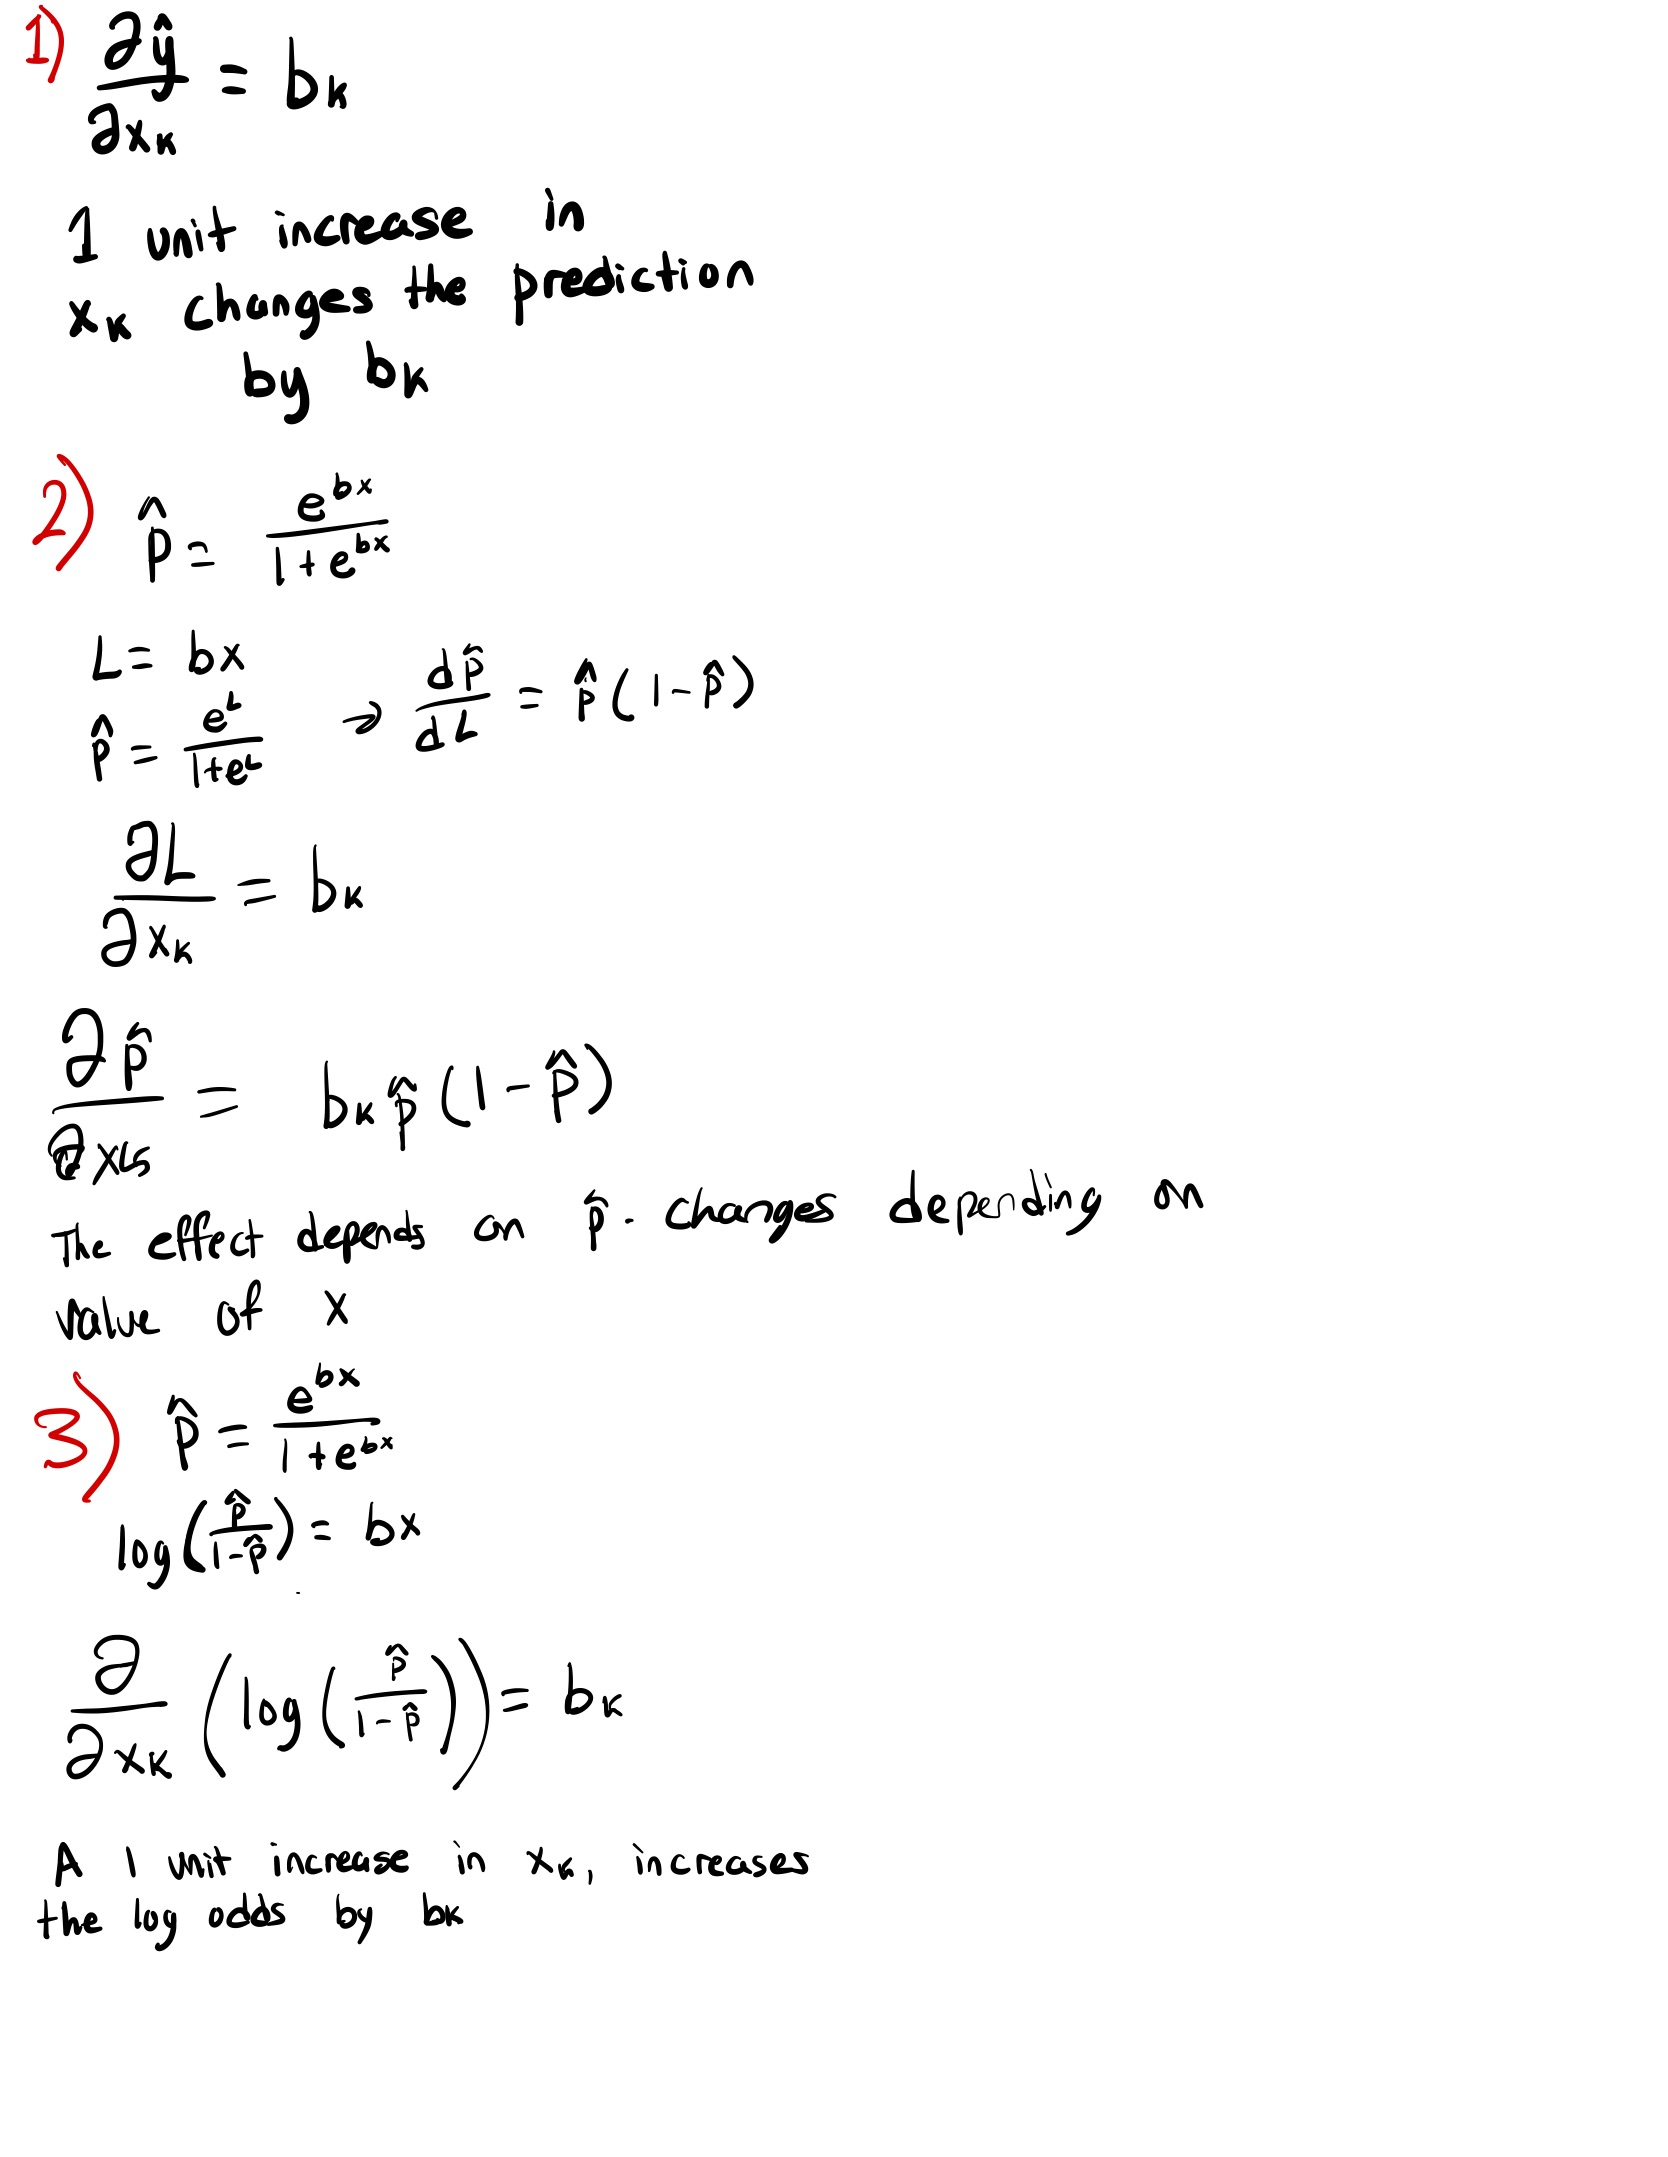

In [16]:
from IPython.display import Image, display

display(Image("data/A5.jpg"))